In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Download dataset
path = kagglehub.dataset_download(
    "vivekattri/global-ev-charging-stations-dataset"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'global-ev-charging-stations-dataset' dataset.
Dataset Path: /kaggle/input/global-ev-charging-stations-dataset


In [ ]:
files = os.listdir(path)

print(files)

csv_file = None

for file in files:
    if file.endswith('.csv'):
        csv_file = file
        break

csv_path = os.path.join(path, csv_file)

df = pd.read_csv(csv_path)

print(df.head())

['detailed_ev_charging_stations.csv']
  Station ID   Latitude   Longitude                                Address  \
0   EVS00001 -33.400998   77.974972       4826 Random Rd, City 98, Country   
1   EVS00002  37.861857 -122.490299  8970 San Francisco Ave, San Francisco   
2   EVS00003  13.776092  100.412776              5974 Bangkok Ave, Bangkok   
3   EVS00004  43.628250  -79.468935              6995 Toronto Ave, Toronto   
4   EVS00005  19.119865   72.913368                5704 Mumbai Ave, Mumbai   

      Charger Type  Cost (USD/kWh) Availability  Distance to City (km)  \
0       AC Level 2            0.27   9:00-18:00                   4.95   
1  DC Fast Charger            0.19         24/7                   4.96   
2       AC Level 2            0.48   6:00-22:00                   8.54   
3       AC Level 1            0.41   9:00-18:00                  13.28   
4       AC Level 2            0.11   9:00-18:00                   9.76   

   Usage Stats (avg users/day) Station Operator 

In [ ]:
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Station ID                   5000 non-null   object 
 1   Latitude                     5000 non-null   float64
 2   Longitude                    5000 non-null   float64
 3   Address                      5000 non-null   object 
 4   Charger Type                 5000 non-null   object 
 5   Cost (USD/kWh)               5000 non-null   float64
 6   Availability                 5000 non-null   object 
 7   Distance to City (km)        5000 non-null   float64
 8   Usage Stats (avg users/day)  5000 non-null   int64  
 9   Station Operator             5000 non-null   object 
 10  Charging Capacity (kW)       5000 non-null   int64  
 11  Connector Types              5000 non-null   object 
 12  Installation Year            5000 non-null   int64  
 13  Renewable Energy S

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values if any
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna('Unknown', inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Cleaning Completed")

Cleaning Completed


/tmp/ipykernel_1051/4191552149.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)
/tmp/ipykernel_1051/4191552149.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [ ]:
# High usage station
df['High Usage Station'] = df['Usage Stats (avg users/day)'].apply(
    lambda x: 1 if x > 50 else 0
)

# Cost category
def cost_category(x):
    if x < 0.20:
        return 'Low Cost'
    elif x < 0.40:
        return 'Medium Cost'
    else:
        return 'High Cost'

df['Cost Category'] = df['Cost (USD/kWh)'].apply(cost_category)

# Capacity utilization score
df['Utilization Score'] = (
    df['Usage Stats (avg users/day)'] /
    df['Charging Capacity (kW)']
)

# Renewable energy flag
df['Renewable Flag'] = df['Renewable Energy Source'].apply(
    lambda x: 1 if x == 'Yes' else 0
)

print(df.head())

  Station ID   Latitude   Longitude                                Address  \
0   EVS00001 -33.400998   77.974972       4826 Random Rd, City 98, Country   
1   EVS00002  37.861857 -122.490299  8970 San Francisco Ave, San Francisco   
2   EVS00003  13.776092  100.412776              5974 Bangkok Ave, Bangkok   
3   EVS00004  43.628250  -79.468935              6995 Toronto Ave, Toronto   
4   EVS00005  19.119865   72.913368                5704 Mumbai Ave, Mumbai   

      Charger Type  Cost (USD/kWh) Availability  Distance to City (km)  \
0       AC Level 2            0.27   9:00-18:00                   4.95   
1  DC Fast Charger            0.19         24/7                   4.96   
2       AC Level 2            0.48   6:00-22:00                   8.54   
3       AC Level 1            0.41   9:00-18:00                  13.28   
4       AC Level 2            0.11   9:00-18:00                   9.76   

   Usage Stats (avg users/day) Station Operator  ...  Connector Types  \
0            

In [ ]:
print(df.describe())

print("\nData Types:\n")
print(df.dtypes)

          Latitude    Longitude  Cost (USD/kWh)  Distance to City (km)  \
count  5000.000000  5000.000000     5000.000000            5000.000000   
mean     19.942607     8.833487        0.300196              10.201810   
std      32.315818    93.724046        0.115733               5.608316   
min     -89.680850  -178.870028        0.100000               0.500000   
25%      13.758953   -87.680319        0.200000               5.430000   
50%      34.029053    18.495233        0.300000              10.190000   
75%      41.840249   100.454629        0.400000              14.902500   
max      89.464534   179.664661        0.500000              20.000000   

       Usage Stats (avg users/day)  Charging Capacity (kW)  Installation Year  \
count                  5000.000000             5000.000000        5000.000000   
mean                     55.453800              144.272000        2016.569400   
std                      26.494986              128.370674           4.004746   
min      

In [ ]:
processed_file = "processed_ev_data.csv"

df.to_csv(processed_file, index=False)

print("Processed dataset saved successfully")

Processed dataset saved successfully


In [ ]:
operator_usage = df.groupby(
    'Station Operator'
)['Usage Stats (avg users/day)'].mean()

print(operator_usage)

Station Operator
ChargePoint    55.724104
EVgo           56.658683
Greenlots      56.212766
Ionity         54.648262
Tesla          54.054422
Name: Usage Stats (avg users/day), dtype: float64


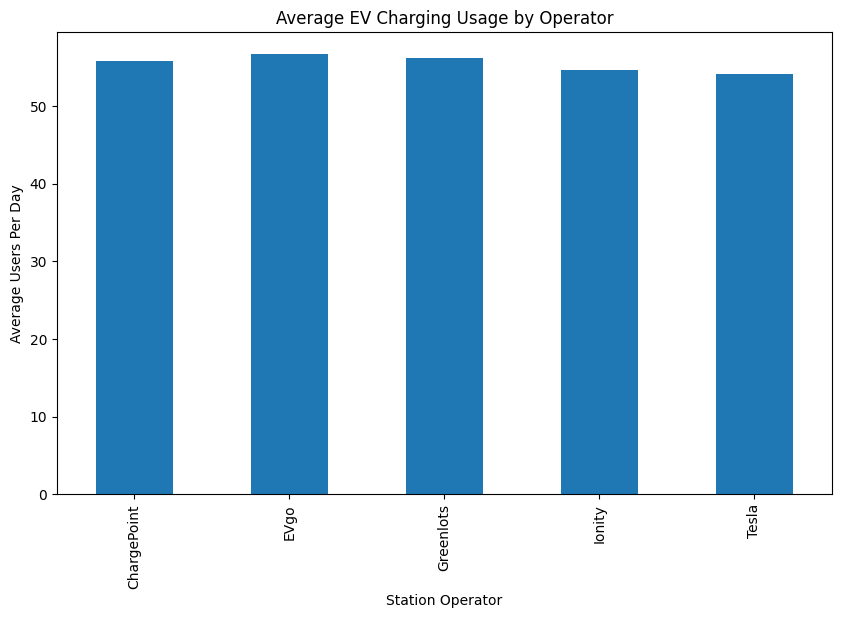

In [ ]:
plt.figure(figsize=(10,6))

operator_usage.plot(kind='bar')

plt.xlabel('Station Operator')

plt.ylabel('Average Users Per Day')
plt.title('Average EV Charging Usage by Operator')

plt.show()

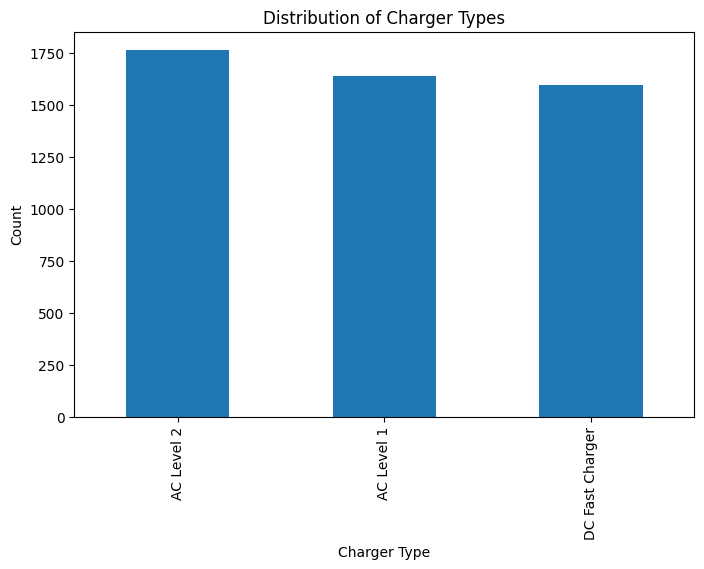

In [ ]:
charger_counts = df['Charger Type'].value_counts()

plt.figure(figsize=(8,5))

charger_counts.plot(kind='bar')

plt.xlabel('Charger Type')
plt.ylabel('Count')
plt.title('Distribution of Charger Types')

plt.show()

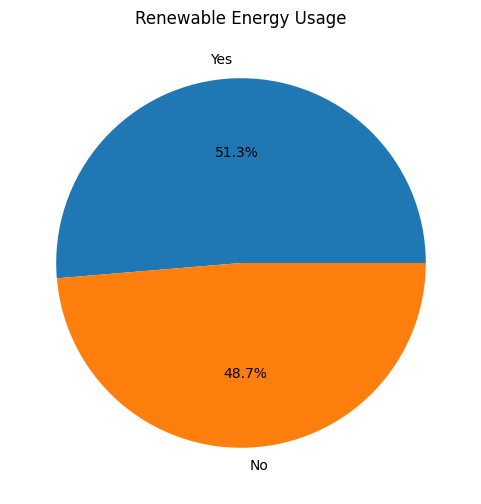

In [ ]:
renewable_counts = df['Renewable Energy Source'].value_counts()

plt.figure(figsize=(6,6))

renewable_counts.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel('')
plt.title('Renewable Energy Usage')

plt.show()

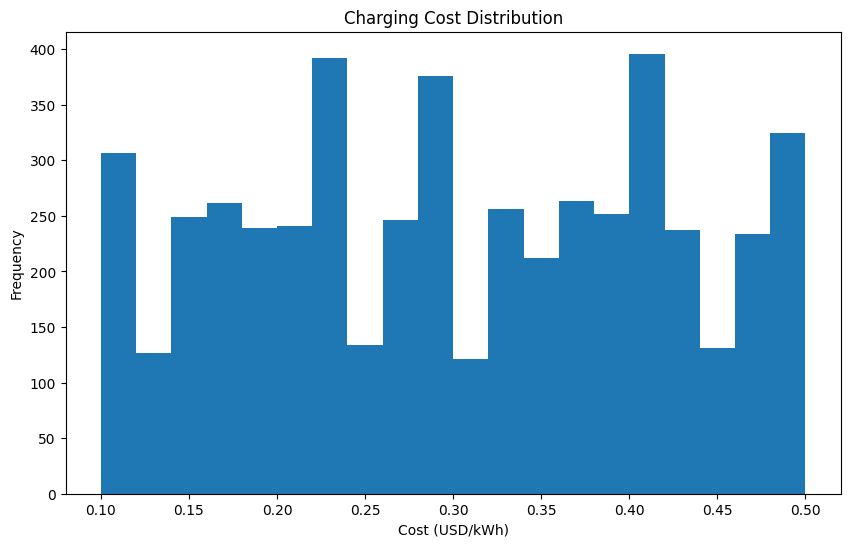

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df['Cost (USD/kWh)'], bins=20)

plt.xlabel('Cost (USD/kWh)')
plt.ylabel('Frequency')
plt.title('Charging Cost Distribution')

plt.show()

In [ ]:
print("\n========== BUSINESS INSIGHTS ==========\n")

print("Top Operator by Usage:")
print(operator_usage.idxmax())

print("\nAverage Charging Cost:")
print(df['Cost (USD/kWh)'].mean())

print("\nStations Using Renewable Energy:")
print(df['Renewable Flag'].sum())

print("\nMost Common Charger Type:")
print(df['Charger Type'].mode()[0])

print("\nHighest Rated Operator:")
print(
    df.groupby('Station Operator')['Reviews (Rating)']
    .mean()
    .idxmax()
)


========== BUSINESS INSIGHTS ==========

Top Operator by Usage:
EVgo

Average Charging Cost:
0.300196

Stations Using Renewable Energy:
2566

Most Common Charger Type:
AC Level 2

Highest Rated Operator:
Tesla


In [ ]:
print("\n===================================")
print("SMART EV PIPELINE EXECUTED SUCCESSFULLY")
print("PROJECT COMPLETED")
print("===================================")


SMART EV PIPELINE EXECUTED SUCCESSFULLY
PROJECT COMPLETED


In [ ]:
df.to_csv(processed_file, index=False)